HLS（Harmonized Landsat Sentinel-2）から NDVI 時系列を取得するスクリプト。

Jupyter Notebook で使う場合:
  各 [Cell N] のコードを、新しいセルに貼り付けてください。

HLS の特徴:
  - NASA/HLSL30/v2_0 : Landsat 8/9 ベース（30m, 16日周期）
  - NASA/HLSS30/v2_0 : Sentinel-2 ベース（30m, 5日周期）
  - 両方を合わせると 2~3日に1回程度の観測
  - 大気補正済み（Level-2A）
  - 2013年〜現在まで完全アーカイブ（2015年も取得可能）
"""

[Cell 1] 認証（初回のみ）

In [3]:
import ee
ee.Authenticate()

True

[Cell 2] GEE 初期化

In [4]:
import ee

GCP_PROJECT = 'ndvi-505105'  # <- 自分の GCP プロジェクト ID に変更

ee.Initialize(project=GCP_PROJECT)
print('GEE 接続成功！')
print(f'  使用プロジェクト: {GCP_PROJECT}')

GEE 接続成功！
  使用プロジェクト: ndvi-505105


[Cell 3] 圃場データの読み込み

In [5]:
import sqlite3
import pandas as pd

FIELD_DB = '../../data/processed/FieldData_fieldid.db'

conn = sqlite3.connect(FIELD_DB)
fields_df = pd.read_sql("""
    SELECT field_id, year, lat, lon, yield
    FROM Questionaire
    WHERE lat IS NOT NULL AND lon IS NOT NULL AND yield IS NOT NULL
    ORDER BY field_id, year
""", conn)
conn.close()

fields_df['field_id'] = fields_df['field_id'].astype(int)
fields_df['year']     = fields_df['year'].astype(int)
fields_df['lat']      = pd.to_numeric(fields_df['lat'], errors='coerce')
fields_df['lon']      = pd.to_numeric(fields_df['lon'], errors='coerce')

print(f'圃場数: {fields_df["field_id"].nunique()} 圃場')
print(f'対象年: {sorted(fields_df["year"].unique().tolist())}')
fields_df.head()

圃場数: 603 圃場
対象年: [2015, 2016, 2017, 2018]


,field_id,year,lat,lon,yield
0,1,2016,43.117144,141.720880,362.581300
1,2,2016,43.170298,141.721513,307.841668
2,3,2016,43.146282,141.744142,92.679090
3,4,2016,43.297893,141.703895,431.459001
4,5,2016,43.313596,141.699987,272.666353


[Cell 4] HLS NDVI 取得関数

 データセット:
   HLSL30 v2.0 : Landsat 8/9  赤=B04, 近赤外=B05
   HLSS30 v2.0 : Sentinel-2   赤=B04, 近赤外=B8A

 雲マスク:
   Fmask バンドのビットフラグを使用
     Bit 1 : Cloud
     Bit 2 : Cloud Shadow
     Bit 3 : Adjacent to Cloud/Shadow
     Bit 4 : Snow/Ice
     Bit 5 : Water

In [20]:
import ee
import pandas as pd

def get_ndvi_timeseries_hls(lat, lon, year, buffer_m=100,
                             apply_cloud_mask=True, verbose=True):
    """
    HLS（Harmonized Landsat Sentinel-2）から NDVI 時系列を取得する。

    HLSL30（Landsat 8/9）と HLSS30（Sentinel-2）を両方取得・結合するため、
    Sentinel-2 単体では欠損が多い 2015〜2016 年でも安定してデータを取得できる。

    Args:
        lat             (float): 緯度
        lon             (float): 経度
        year            (int)  : 対象年
        buffer_m        (int)  : バッファ半径[m]（デフォルト 100m）
                                 HLS の解像度は 30m。最低でも 100m 推奨。
        apply_cloud_mask (bool): Fmask による雲マスクを適用するか
        verbose         (bool) : デバッグ情報を表示するか

    Returns:
        pd.DataFrame: date, NDVI, n_pixels, source 列
    """
    point = ee.Geometry.Point([lon, lat])
    aoi   = point.buffer(buffer_m)

    start_date = f'{year}-05-15'
    end_date   = f'{year}-11-30'

    # ── 現在（厳格：雲・影・隣接・雪・水をすべて除外）──
    #CLOUD_BITMASK = (1 << 1) | (1 << 2) | (1 << 3) | (1 << 4) | (1 << 5)
    # ── 緩め（雲本体と影のみ除外）──
    CLOUD_BITMASK = (1 << 1) | (1 << 2) | (1 << 3)

    def mask_hls_clouds(img):
        fmask = img.select('Fmask')
        mask  = fmask.bitwiseAnd(CLOUD_BITMASK).eq(0)
        return img.updateMask(mask)

    # ── HLSL30: Landsat 8/9 (赤=B04, 近赤外=B05) ────────────
    def add_ndvi_l30(img):
        ndvi = img.normalizedDifference(['B5', 'B4']).rename('NDVI')  # L30: 赤=B4, 近赤外=B5
        return img.addBands(ndvi)

    l30_raw = (
        ee.ImageCollection('NASA/HLS/HLSL30/v002')  # 正しいGEEカタログID
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
    )
    l30 = (l30_raw.map(mask_hls_clouds) if apply_cloud_mask else l30_raw)
    l30 = l30.map(add_ndvi_l30).select('NDVI').map(
        lambda img: img.set('source', 'L30')
    )

    # ── HLSS30: Sentinel-2 (赤=B04, 近赤外=B8A) ─────────────
    def add_ndvi_s30(img):
        ndvi = img.normalizedDifference(['B8A', 'B4']).rename('NDVI')  # S30: 赤=B4, 近赤外=B8A
        return img.addBands(ndvi)

    s30_raw = (
        ee.ImageCollection('NASA/HLS/HLSS30/v002')  # 正しいGEEカタログID
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
    )
    s30 = (s30_raw.map(mask_hls_clouds) if apply_cloud_mask else s30_raw)
    s30 = s30.map(add_ndvi_s30).select('NDVI').map(
        lambda img: img.set('source', 'S30')
    )

    # ── 2つのコレクションをマージ ────────────────────────────
    hls_merged = l30.merge(s30)

    if verbose:
        n_l30 = l30_raw.size().getInfo()
        n_s30 = s30_raw.size().getInfo()
        print(f'  [DEBUG] HLSL30 (Landsat) : {n_l30} シーン')
        print(f'  [DEBUG] HLSS30 (Sentinel): {n_s30} シーン')
        print(f'  [DEBUG] 合計             : {n_l30 + n_s30} シーン')

    # ── 各画像から NDVI 平均・ピクセル数を抽出 ───────────────
    def extract_value(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean().combine(
                ee.Reducer.count(), sharedInputs=True
            ),
            geometry=aoi,
            scale=30,          # HLS の解像度は 30m
            bestEffort=True,
        )
        return ee.Feature(None, {
            'date':     ee.Date(img.get('system:time_start')).format('YYYY-MM-dd'),
            'NDVI':     stats.get('NDVI_mean'),
            'n_pixels': stats.get('NDVI_count'),
            'source':   img.get('source'),
        })

    fc = hls_merged.map(extract_value).getInfo()

    rows = []
    for feat in fc['features']:
        p = feat['properties']
        rows.append({
            'date':     p.get('date'),
            'NDVI':     p.get('NDVI'),
            'n_pixels': p.get('n_pixels'),
            'source':   p.get('source'),
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df['date']     = pd.to_datetime(df['date'])
    df['NDVI']     = pd.to_numeric(df['NDVI'],     errors='coerce')
    df['n_pixels'] = pd.to_numeric(df['n_pixels'], errors='coerce')

    # n_pixels > 0 のみ残す
    df = df[df['n_pixels'] > 0]

    if verbose:
        n_valid = len(df.dropna(subset=['NDVI']))
        print(f'  [DEBUG] 有効シーン数 (NDVI取得済み): {n_valid}')

    return df.dropna(subset=['NDVI']).sort_values('date').reset_index(drop=True)

[Cell 5] 実行 — 1 圃場でテスト

In [21]:
TARGET_FIELD_ID = 146
TARGET_YEAR     = 2018

row = fields_df[
    (fields_df['field_id'] == TARGET_FIELD_ID) &
    (fields_df['year']     == TARGET_YEAR)
]

if row.empty:
    print(f'field_id={TARGET_FIELD_ID}, year={TARGET_YEAR} のデータが見つかりません')
else:
    lat = float(row.iloc[0]['lat'])
    lon = float(row.iloc[0]['lon'])
    print(f'対象圃場: field_id={TARGET_FIELD_ID}  year={TARGET_YEAR}')
    print(f'  緯度: {lat:.6f}  経度: {lon:.6f}')
    print(f'  実測収量: {float(row.iloc[0]["yield"]):.1f} kg/10a')
    print()

    # ── 雲マスクあり ──────────────────────────────────────────
    print('=== 雲マスクあり（Fmask適用）===')
    ndvi_df = get_ndvi_timeseries_hls(lat, lon, TARGET_YEAR,
                                      buffer_m=100,
                                      apply_cloud_mask=True,
                                      verbose=True)
    print(f'取得完了！  {len(ndvi_df)} 件のデータポイント')
    print(ndvi_df.to_string())
    print()

    # ── 雲マスクなし ──────────────────────────────────────────
    print('=== 雲マスクなし（全シーン）===')
    ndvi_raw_df = get_ndvi_timeseries_hls(lat, lon, TARGET_YEAR,
                                          buffer_m=100,
                                          apply_cloud_mask=False,
                                          verbose=True)
    print(f'取得完了！  {len(ndvi_raw_df)} 件のデータポイント')
    print(ndvi_raw_df.to_string())


対象圃場: field_id=146  year=2018
  緯度: 36.422250  経度: 136.439583
  実測収量: 267.3 kg/10a

=== 雲マスクあり（Fmask適用）===
  [DEBUG] HLSL30 (Landsat) : 22 シーン
  [DEBUG] HLSS30 (Sentinel): 1060 シーン
  [DEBUG] 合計             : 1082 シーン
  [DEBUG] 有効シーン数 (NDVI取得済み): 25
取得完了！  25 件のデータポイント
         date      NDVI  n_pixels source
0  2018-05-21  0.548820        45    S30
1  2018-06-25  0.219408        45    L30
2  2018-07-02  0.228735        45    L30
3  2018-07-10  0.324301        45    S30
4  2018-07-11  0.321523        45    L30
5  2018-07-15  0.355947        45    S30
6  2018-07-18  0.387439        45    L30
7  2018-07-20  0.415504        45    S30
8  2018-07-27  0.533021        45    L30
9  2018-07-30  0.606197        45    S30
10 2018-08-03  0.657296        45    L30
11 2018-08-04  0.678333        45    S30
12 2018-08-14  0.779020        45    S30
13 2018-09-03  0.788045        45    S30
14 2018-09-18  0.697267        45    S30
15 2018-09-28  0.668368        45    S30
16 2018-10-03  0.602627        45 

[Cell 6] プロット

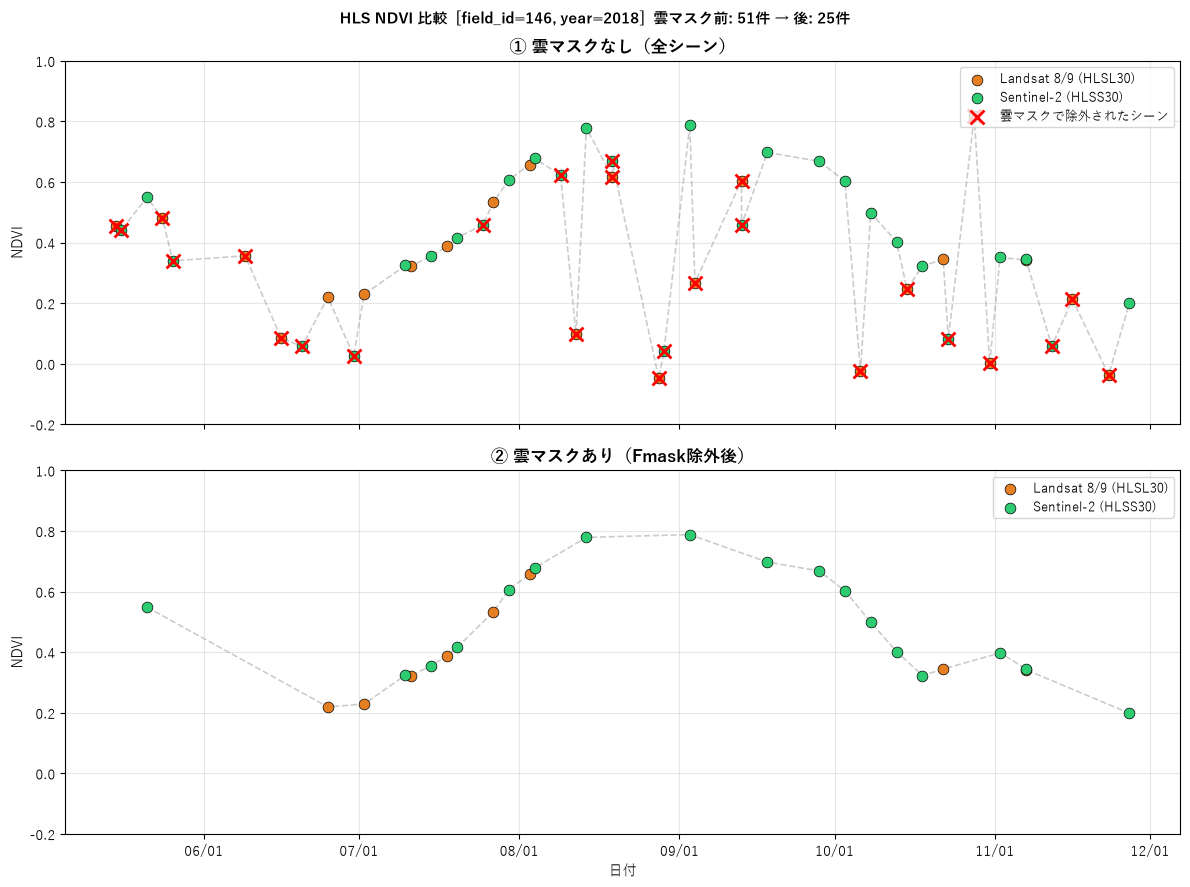

プロット保存: ../../outputs/hls_ndvi_compare_field146_2018.png

--- NDVI 基本統計（雲マスクあり）---
  観測日数  : 25
  NDVI 最大 : 0.788
  NDVI 平均 : 0.467
  NDVI 最小 : 0.199


In [22]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import os

_jp_fonts  = ['Yu Gothic', 'MS Gothic', 'Meiryo', 'IPAexGothic', 'Noto Sans CJK JP']
_available = {f.name for f in fm.fontManager.ttflist}
_font      = next((f for f in _jp_fonts if f in _available), None)
if _font:
    plt.rcParams['font.family'] = _font
plt.rcParams['axes.unicode_minus'] = False

os.makedirs('../../outputs', exist_ok=True)

COLOR_MAP = {'L30': '#e67e22', 'S30': '#2ecc71'}
LABEL_MAP = {'L30': 'Landsat 8/9 (HLSL30)', 'S30': 'Sentinel-2 (HLSS30)'}

if 'ndvi_df' in dir() and 'ndvi_raw_df' in dir():
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

    # ── 上グラフ：雲マスクなし（全シーン）───────────────────
    for src, grp in ndvi_raw_df.groupby('source'):
        ax1.scatter(grp['date'], grp['NDVI'],
                    color=COLOR_MAP.get(src, 'gray'),
                    s=60, zorder=3, label=LABEL_MAP.get(src, src),
                    edgecolors='black', linewidths=0.5)
    ax1.plot(ndvi_raw_df['date'], ndvi_raw_df['NDVI'],
             color='gray', alpha=0.4, lw=1.2, linestyle='--', zorder=2)

    # 雲マスクで除外されたシーンを×マーカーで重ねて表示
    masked_dates = set(ndvi_raw_df['date']) - set(ndvi_df['date'])
    removed = ndvi_raw_df[ndvi_raw_df['date'].isin(masked_dates)]
    if not removed.empty:
        ax1.scatter(removed['date'], removed['NDVI'],
                    marker='x', color='red', s=100, lw=2, zorder=4,
                    label='雲マスクで除外されたシーン')

    ax1.set_title('① 雲マスクなし（全シーン）', fontsize=12, fontweight='bold')
    ax1.set_ylabel('NDVI')
    ax1.set_ylim(-0.2, 1.0)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right', fontsize=9)

    # ── 下グラフ：雲マスクあり（有効シーンのみ）─────────────
    for src, grp in ndvi_df.groupby('source'):
        ax2.scatter(grp['date'], grp['NDVI'],
                    color=COLOR_MAP.get(src, 'gray'),
                    s=60, zorder=3, label=LABEL_MAP.get(src, src),
                    edgecolors='black', linewidths=0.5)
    ax2.plot(ndvi_df['date'], ndvi_df['NDVI'],
             color='gray', alpha=0.4, lw=1.2, linestyle='--', zorder=2)

    ax2.set_title('② 雲マスクあり（Fmask除外後）', fontsize=12, fontweight='bold')
    ax2.set_ylabel('NDVI')
    ax2.set_xlabel('日付')
    ax2.set_ylim(-0.2, 1.0)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator())
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right', fontsize=9)

    fig.suptitle(
        f'HLS NDVI 比較  [field_id={TARGET_FIELD_ID}, year={TARGET_YEAR}]  '
        f'雲マスク前: {len(ndvi_raw_df)}件 → 後: {len(ndvi_df)}件',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()

    save_path = f'../../outputs/hls_ndvi_compare_field{TARGET_FIELD_ID}_{TARGET_YEAR}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'プロット保存: {save_path}')

    print('\n--- NDVI 基本統計（雲マスクあり）---')
    print(f'  観測日数  : {len(ndvi_df)}')
    print(f'  NDVI 最大 : {ndvi_df["NDVI"].max():.3f}')
    print(f'  NDVI 平均 : {ndvi_df["NDVI"].mean():.3f}')
    print(f'  NDVI 最小 : {ndvi_df["NDVI"].min():.3f}')

else:
    print('ndvi_df / ndvi_raw_df が未定義です。Cell 5 を先に実行してください。')
